In [2]:
import pandas as pd
import matplotlib.pyplot as plt

The direct matching dataset contains the best 10 candidates for each job position. In this case we are only looking at job offers

In [3]:
#path to be changed with correct one for your device
dm_df = pd.read_csv(r'C:\Users\annad\Desktop\AI_in_industry\Adecco_Dataset\direct_matching_20240213_eng.csv', encoding='Windows-1252', sep = ';')

In [4]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,3.232.704.163,9.957.338.715,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
1,"4,999,120",OFF_1011_1427,155.955.925,9.921.056.366,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
2,"5,413,671",OFF_1011_1427,3.134.887.695,991.186.142,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
3,"5,965,090",OFF_1011_1427,6.631.559.753,9.740.976.715,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
4,"5,771,219",OFF_1011_1427,155.955.925,9.732.387.543,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD


The reverse matching dataset contains the best 5 offers (job positions published on Adecco website) and the best 5 orders (job position managed internally without publishing on Adecco website) for each candidate

In [5]:
#path to be changed with correct one for your device
rm_df = pd.read_csv(r'C:\Users\annad\Desktop\AI_in_industry\Adecco_Dataset\reverse_matching_20240213_eng.csv', encoding='Windows-1252', sep=';')

In [6]:
rm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"11,208",OFF_3435_4864,30.609745,99.309860,1,Female,25-34,VE,VENETO,"Master's Degree: Economics for arts, culture a...",Search and selection,secretary/secretary,Secretariat / General Services,TV
1,"11,208",ORD_13361_0218,42.466312,96.529259,1,Female,25-34,VE,VENETO,"Master's Degree: Economics for arts, culture a...",Subordinate employment,Employee (m/f),Secretariat / General Services,PN
2,"11,208",ORD_14183_0606,33.240650,95.374954,2,Female,25-34,VE,VENETO,"Master's Degree: Economics for arts, culture a...",Subordinate employment,Human Resources Officer (m/f),Human Resources / Recruitment,TV
3,"11,208",OFF_635_0402,58.744339,94.199844,2,Female,25-34,VE,VENETO,"Master's Degree: Economics for arts, culture a...",Search and selection,Telemarketing operator,Call Center / Customer Care,PD
4,"11,208",OFF_5814_0606,27.851854,93.688522,3,Female,25-34,VE,VENETO,"Master's Degree: Economics for arts, culture a...",Subordinate employment,Administrative Assistant,Finance / Accounting,TV


...Checking for duplicates in both dataframes

It makes sense to define what constitutes a duplicate in each dataframe. In this case:
- for the direct matching, we need to check if for each job_id we have the same candidate twice (because the dataframe represents, for each job, the 10 best candidates)
- for the inverse matching instead we have for each candidate the best job, therefore it makes sense to check if for the same candidate the same job is repeated multiple times

In [7]:
print(dm_df.duplicated(subset=['job_id', 'cand_id']).sum())
print(rm_df.duplicated(subset=['cand_id', 'job_id']).sum())

0
0


There are no duplicates defined as above in either of the dataframes, therefore there is no action ot do

...Checking for null values in both dataframes

In [8]:
numna_dm = dm_df.isna().sum().sum()
numna_rm = rm_df.isna().sum().sum()
print(f'Total number of null values in direct matching dataframe is {numna_dm}')
print(f'Total number of null values in reverse matching dataframe is {numna_rm}')

Total number of null values in direct matching dataframe is 6314
Total number of null values in reverse matching dataframe is 150729


# DELETE THIS CELL

Handling missing values by dropping them

I don't know if it makes sense to remove a candidate because they do not have an education indicated (NaN) even if the match rank is extremely high. I think that I can delete a column only if the ids are null or something like that, which would invalidate the whole row. But if a row contains another row as null it makes no sense to delete it. 

In [9]:
dm_df = dm_df.dropna(subset=['cand_id', 'job_id', 'match_score', 'match_rank'])

In [10]:
rm_df = rm_df.dropna(subset=['cand_id', 'job_id', 'match_score', 'match_rank'])

Now we explore the columns and which would be the most useful for the given task.

In [11]:
dm_df.columns

Index(['cand_id', 'job_id', 'distance_km', 'match_score', 'match_rank',
       'cand_gender', 'cand_age_bucket', 'cand_domicile_province',
       'cand_domicile_region', 'cand_education', 'job_contract_type',
       'job_professional_category', 'job_sector', 'job_work_province'],
      dtype='object')

In [12]:
rm_df.columns

Index(['cand_id', 'job_id', 'distance_km', 'match_score', 'match_rank',
       'cand_gender', 'cand_age_bucket', 'cand_domicile_province',
       'cand_domicile_region', 'cand_education', 'job_contract_type',
       'job_professional_category', 'job_sector', 'job_work_province'],
      dtype='object')

The columns are the same in both dataframes, and they are all useful when we are going to understand what are the characteristics which are most important and influential when determining the fit of a candidate. 

# DELETE THIS CELL 
### Things I think need to be done
- group the first dataframe by job and the second one by candidate
- for the first one check what the first candidates (spot #1) have in common (like, do they all live close to the job? are they all young/old etc)
- for the second one check if a candidate is more suited for an internal promotion or an external job offer
- in both check for some distributions of the dataframe itself, like how many candidates are in each age bracket, or the place of birth of the candidates. These are only to understand better the candidates themselves
- UNDERSTAND WHAT THE RANKING MEANS, AND WHY WE HAVE TWO COLUMNS MATCH SCORE AND MATCH RANK
- for the second one check the most common contract type and things like this 
- maybe it is a good idea to remove the job-related columns from the first and the candidate-related columns from the second (???????)
- check things like the gender of the top applicant according to the job sector, or the provenance of the top applicant according to job_work province
- check the opposite, so the job sector of the top job according to the candidate and things like this. 

## EXAMPLE WORK ON THE FIRST DATAFRAME - DIRECT MATCHING

In [13]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,3.232.704.163,9.957.338.715,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
1,"4,999,120",OFF_1011_1427,155.955.925,9.921.056.366,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
2,"5,413,671",OFF_1011_1427,3.134.887.695,991.186.142,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
3,"5,965,090",OFF_1011_1427,6.631.559.753,9.740.976.715,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
4,"5,771,219",OFF_1011_1427,155.955.925,9.732.387.543,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD


In [14]:
# Print the total number of NaN values for each column
print(dm_df.isna().sum())

cand_id                         0
job_id                          0
distance_km                     0
match_score                     0
match_rank                      0
cand_gender                     0
cand_age_bucket                 1
cand_domicile_province          3
cand_domicile_region            5
cand_education               6305
job_contract_type               0
job_professional_category       0
job_sector                      0
job_work_province               0
dtype: int64


In [15]:
#the null values are substituted with default values
dm_df['cand_education'] = dm_df['cand_education'].fillna('Not disclosed')
dm_df['cand_age_bucket'] = dm_df['cand_age_bucket'].fillna('Not disclosed')
dm_df['cand_domicile_province'] = dm_df['cand_domicile_province'].fillna('Not disclosed')
dm_df['cand_domicile_region'] = dm_df['cand_domicile_region'].fillna('Not disclosed')

In [16]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,3.232.704.163,9.957.338.715,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
1,"4,999,120",OFF_1011_1427,155.955.925,9.921.056.366,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
2,"5,413,671",OFF_1011_1427,3.134.887.695,991.186.142,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
3,"5,965,090",OFF_1011_1427,6.631.559.753,9.740.976.715,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
4,"5,771,219",OFF_1011_1427,155.955.925,9.732.387.543,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD


Check which are the top applicants for each job id and if they have anything in common

In [17]:
dm_top_applicants = dm_df[dm_df['match_rank'] == 1]
dm_top_applicants.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,3.232.704.163,9.957.338.715,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
10,"5,025,089",OFF_1038_1739,1.778.607.559,9.994.982.147,1,Male,25-34,MI,LOMBARDIA,Degree / High School : Scientific High School,Search and selection,Butcher (m/f),Large-scale distribution / Retail / Shop assis...,MI
20,"7,090,323",OFF_104_1550,2.166.576.576,9.999.417.877,1,Male,35-44,CH,ABRUZZO,Not disclosed,Subordinate employment,welder,Specialized workers,CH
30,"7,243,240",OFF_1042_1739,8.031.867.218,999.752.655,1,Female,45-54,BS,LOMBARDIA,Not disclosed,Search and selection,Head of large-scale retail trade department,Large-scale distribution / Retail / Shop assis...,MI
40,"5,026,884",OFF_111_1704,8.802.752.495,999.732.132,1,Male,45-54,MI,LOMBARDIA,Not disclosed,Subordinate employment,Portal truck driver (m/f),Warehouse / Logistics / Transport,MI


In [18]:
dm_top_applicants.shape

(865, 14)

## Plots and distributions of the values to get insights

### AGE BUCKET

In [19]:
unique_values = dm_df['cand_age_bucket'].unique()
print("Unique values in cand_age_bucket column:", unique_values)

Unique values in cand_age_bucket column: ['45-54' '35-44' '15-24' '55-74' '25-34' 'Not disclosed']


C:\Users\annad\AppData\Local\Temp\ipykernel_35164\2605630338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

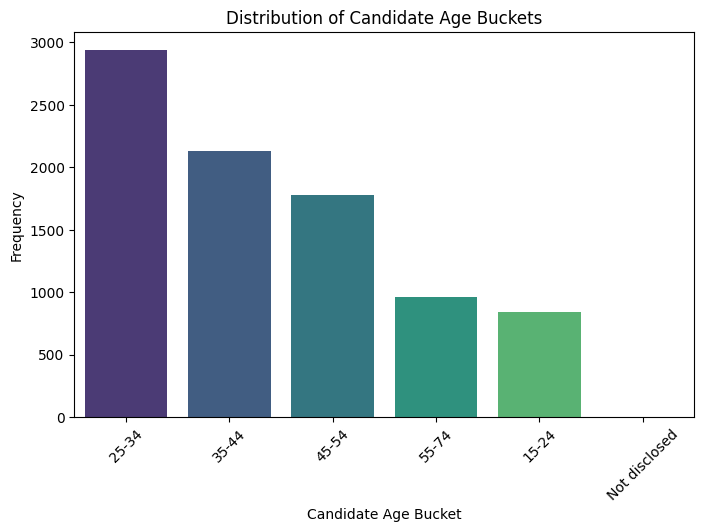

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the unique values
value_counts = dm_df['cand_age_bucket'].value_counts(dropna=False)  # Include NaN values

# Plot the frequency of each unique value
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")

# Add labels and title
plt.xlabel("Candidate Age Bucket")
plt.ylabel("Frequency")
plt.title("Distribution of Candidate Age Buckets")
plt.xticks(rotation=45)
plt.show()


From this plot we can check that the most applicants (in the 10 which are shown in the dataframe) belong to the 25-34 age bucket by a significant margin. 

Now we can check the same thing for the most successful applicants in the dataframe containing only the highly ranked applicants. 

C:\Users\annad\AppData\Local\Temp\ipykernel_35164\2144891771.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

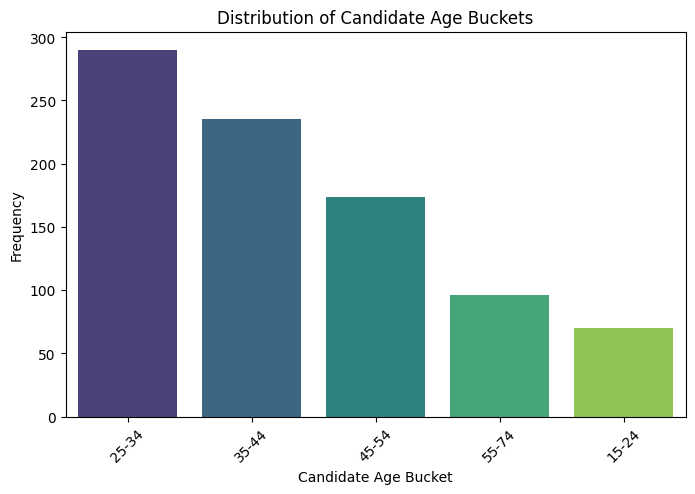

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the unique values
value_counts = dm_top_applicants['cand_age_bucket'].value_counts(dropna=False)  # Include NaN values

# Plot the frequency of each unique value
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")

# Add labels and title
plt.xlabel("Candidate Age Bucket")
plt.ylabel("Frequency")
plt.title("Distribution of Candidate Age Buckets")
plt.xticks(rotation=45)
plt.show()


Also in this case, we notice that the 25-34 bucket looks to be the most successful one. 

### GENDER

In [22]:
unique_values = dm_df['cand_gender'].unique()
print("Unique values in cand_gender column:", unique_values)

Unique values in cand_gender column: ['Male' 'Female']


In [23]:
# Count occurrences of each gender
gender_counts = dm_df['cand_gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Print the percentage of each gender
print("Percentage distribution of candidate genders:\n", gender_counts)

# Find the gender that appears more frequently
most_frequent_gender = gender_counts.idxmax()  # Get the gender with the highest percentage
most_frequent_percentage = gender_counts.max()  # Get the highest percentage

print(f"\nThe gender '{most_frequent_gender}' appears the most, with {most_frequent_percentage:.2f}% of occurrences.")

Percentage distribution of candidate genders:
 cand_gender
Male      55.117382
Female    44.882618
Name: proportion, dtype: float64

The gender 'Male' appears the most, with 55.12% of occurrences.


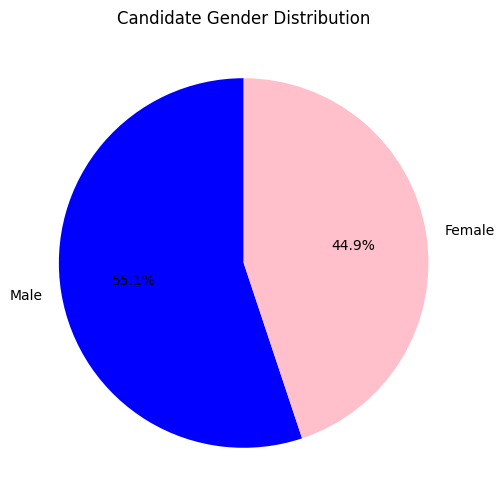

In [24]:
# Pie chart for gender distribution
plt.figure(figsize=(6, 6))
dm_df['cand_gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['blue', 'pink'], startangle=90)
plt.title("Candidate Gender Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


We can see that there is a majority of Male candidates in the 10 selected, with a margin of 10.23%

In [25]:
# Count occurrences of each gender
gender_counts = dm_top_applicants['cand_gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Print the percentage of each gender
print("Percentage distribution of candidate genders:\n", gender_counts)

# Find the gender that appears more frequently
most_frequent_gender = gender_counts.idxmax()  # Get the gender with the highest percentage
most_frequent_percentage = gender_counts.max()  # Get the highest percentage

print(f"\nThe gender '{most_frequent_gender}' appears the most, with {most_frequent_percentage:.2f}% of occurrences.")

Percentage distribution of candidate genders:
 cand_gender
Male      55.83815
Female    44.16185
Name: proportion, dtype: float64

The gender 'Male' appears the most, with 55.84% of occurrences.


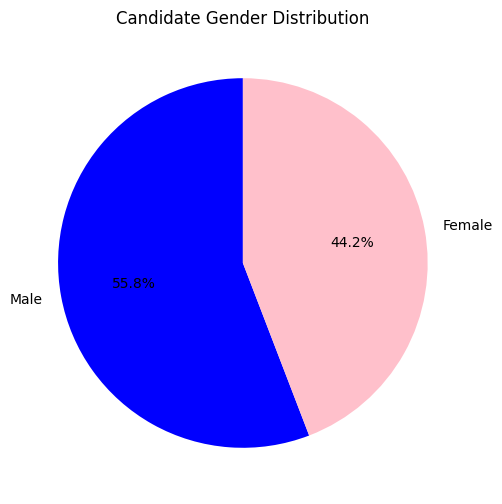

In [26]:
# Pie chart for gender distribution
plt.figure(figsize=(6, 6))
dm_top_applicants['cand_gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['blue', 'pink'], startangle=90)
plt.title("Candidate Gender Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


This margin is more or less maintained in the most successful applicant for each job description. 

### DOMICILE REGION

In [27]:
unique_values = dm_df['cand_domicile_region'].unique()
print("Unique values in cand_domicile_region column:", unique_values)

Unique values in cand_domicile_region column: ['FRIULI VENEZIA GIULIA' 'LOMBARDIA' 'ABRUZZO' 'MOLISE' 'PIEMONTE'
 'VENETO' 'EMILIA ROMAGNA' 'CAMPANIA' "VALLE D'AOSTA" 'LAZIO'
 'TRENTINO ALTO ADIGE' 'SARDEGNA' 'TOSCANA' 'MARCHE' 'LIGURIA'
 'Not disclosed' 'PUGLIA' 'UMBRIA' 'CALABRIA']


In [28]:
# Count occurrences of each region in percentage
region_counts = dm_df['cand_domicile_region'].value_counts(normalize=True) * 100  

# Print percentage distribution
print("Percentage distribution of domicile regions:\n", region_counts)


Percentage distribution of domicile regions:
 cand_domicile_region
LOMBARDIA                46.131606
EMILIA ROMAGNA           14.224587
VENETO                   14.051116
PIEMONTE                  9.378975
FRIULI VENEZIA GIULIA     4.244247
LAZIO                     3.723835
TOSCANA                   3.087776
TRENTINO ALTO ADIGE       1.607494
MARCHE                    1.457153
ABRUZZO                   0.844223
SARDEGNA                  0.358506
LIGURIA                   0.346941
VALLE D'AOSTA             0.231294
UMBRIA                    0.104082
MOLISE                    0.080953
Not disclosed             0.057824
CAMPANIA                  0.034694
PUGLIA                    0.023129
CALABRIA                  0.011565
Name: proportion, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_35164\289213456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(p

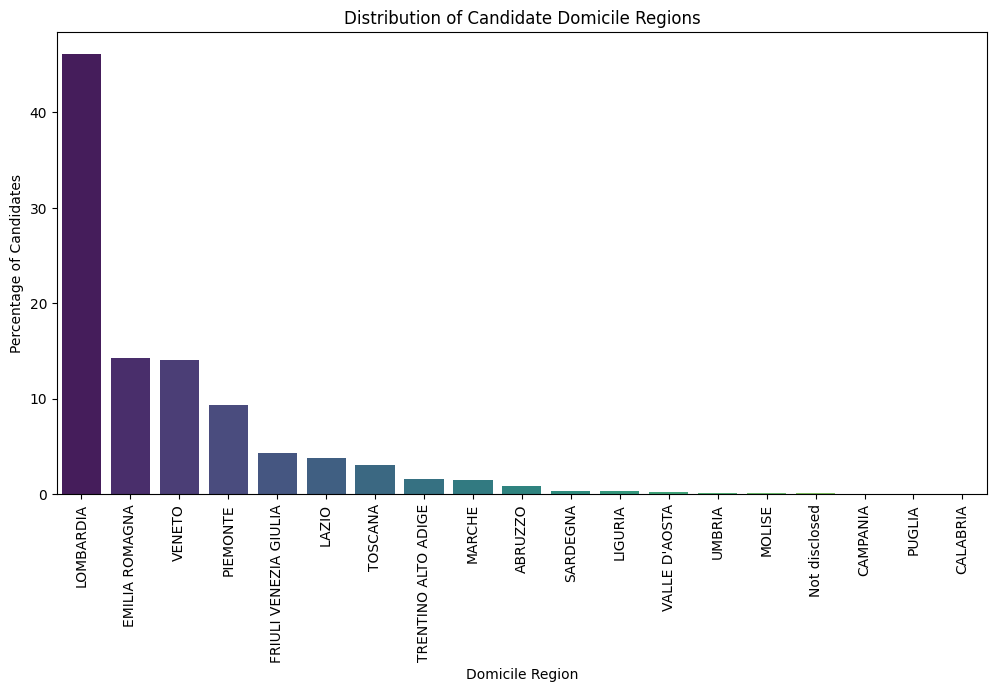

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(12, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Regions")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()


It is evident that the most top 10 candidates come from the LOMBARDIA region, by a huge margin. It is also noticeable that the southern regions of Italy have the least amount of applicants by a significant margin compared to the central and northern regions.

In [30]:
# Count occurrences of each region in percentage
region_counts = dm_top_applicants['cand_domicile_region'].value_counts(normalize=True) * 100  

# Print percentage distribution
print("Percentage distribution of domicile regions:\n", region_counts)


Percentage distribution of domicile regions:
 cand_domicile_region
LOMBARDIA                46.011561
EMILIA ROMAGNA           13.988439
VENETO                   13.988439
PIEMONTE                  9.017341
FRIULI VENEZIA GIULIA     4.277457
LAZIO                     3.815029
TOSCANA                   3.815029
TRENTINO ALTO ADIGE       1.734104
MARCHE                    1.502890
ABRUZZO                   0.693642
LIGURIA                   0.462428
SARDEGNA                  0.346821
VALLE D'AOSTA             0.231214
UMBRIA                    0.115607
Name: proportion, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_35164\2820394445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(

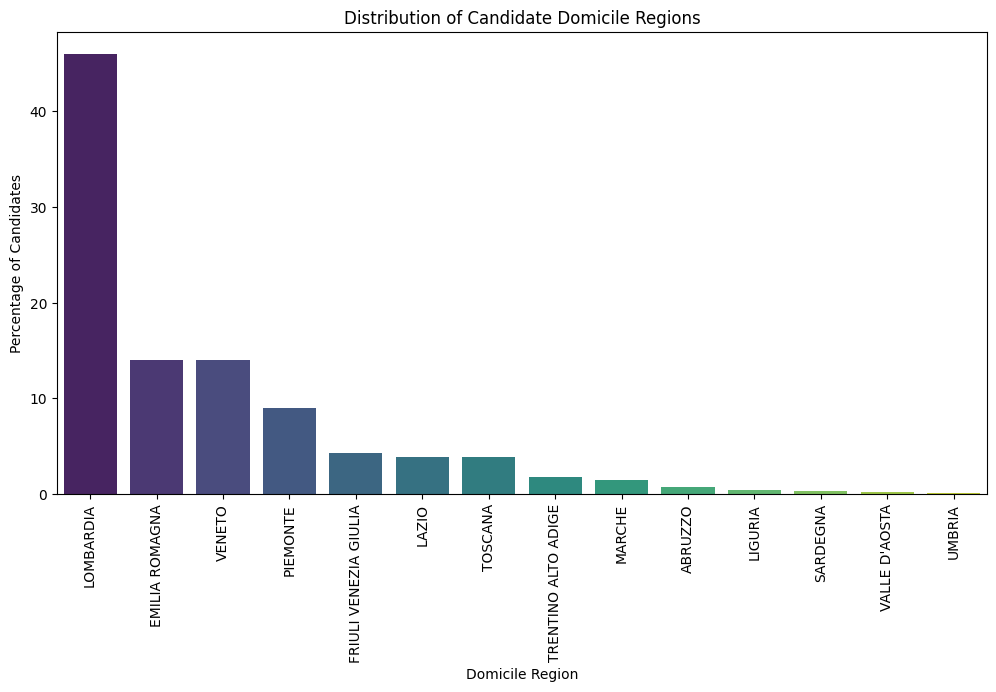

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(12, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Regions")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()

In the top applicants, the southern regions don't appear, indicating that no applicant from those was considered a successful candidate. 

### DOMICILE PROVINCE

In [32]:
unique_values = dm_df['cand_domicile_province'].unique()
print("Unique values in cand_domicile_province column:", unique_values)

Unique values in cand_domicile_province column: ['UD' 'TS' 'GO' 'MI' 'MB' 'BG' 'CH' 'CB' 'BS' 'AL' 'VA' 'NO' 'VR' 'MN'
 'CO' 'PR' 'CR' 'PV' 'TO' 'PN' 'PC' 'BL' 'MO' 'BO' 'LC' 'LO' 'BI' 'VC'
 'CN' 'AT' 'PD' 'TV' 'VE' 'RE' 'RO' 'Not disclosed' 'VI' 'AO' 'RM' 'FR'
 'LT' 'RI' 'FE' 'TN' 'CA' 'PE' 'PO' 'FC' 'AQ' 'FM' 'MC' 'GE' 'SC' 'BT'
 'FI' 'PI' 'LI' 'LU' 'PT' 'AN' 'SI' 'MS' 'PU' 'AP' 'TE' 'RN' 'RA' 'SV'
 'BZ' 'AR' 'SO' 'VT' 'IS' 'PG' 'CS' 'IM' 'OR' 'NU' 'SU' 'CE']


In [33]:
# Count occurrences of each region in percentage
province_counts = dm_df['cand_domicile_province'].value_counts(normalize=True) * 100  

# Print percentage distribution
print("Percentage distribution of domicile provinces:\n", province_counts)


Percentage distribution of domicile provinces:
 cand_domicile_province
MI    15.508269
BG    10.142246
BS     8.696658
TO     5.851740
BO     5.539493
        ...    
IS     0.023129
MS     0.011565
CS     0.011565
VT     0.011565
CE     0.011565
Name: proportion, Length: 80, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_35164\1337462310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_gr

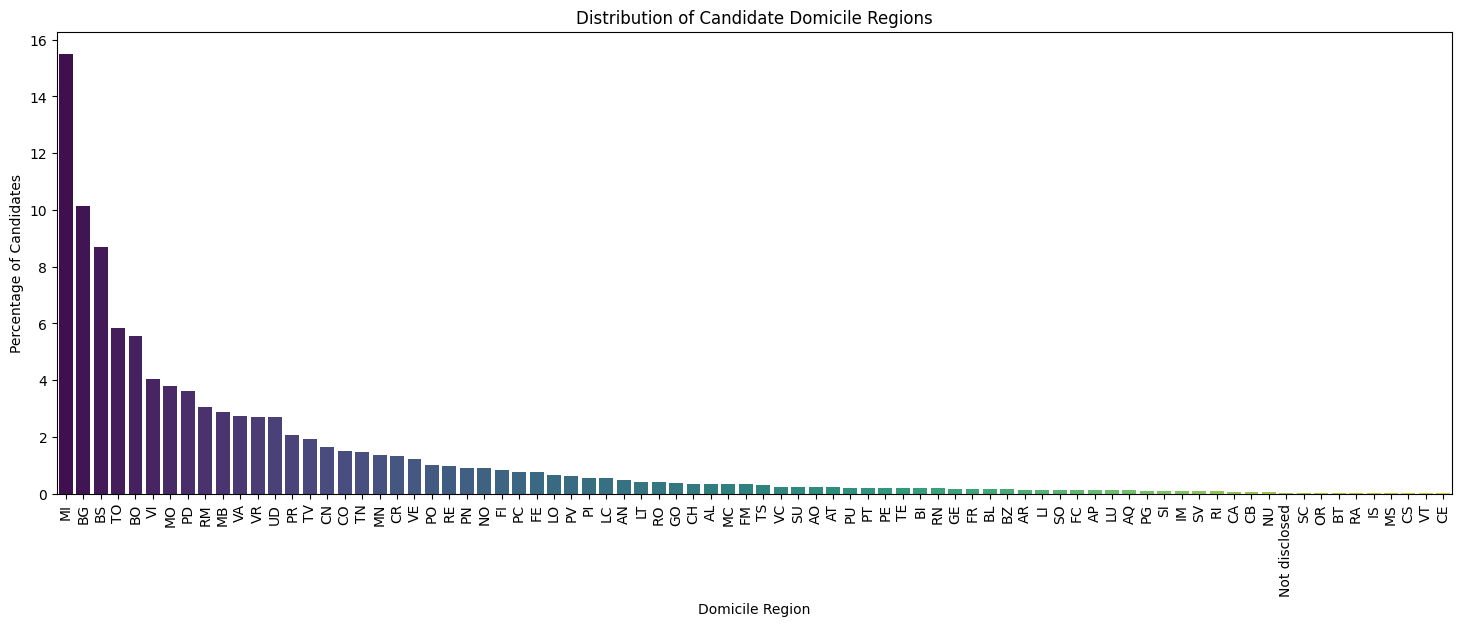

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(18, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Regions")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()


Most candidates come from the three main Lombardy provinces: Milano, Bergamo and Brescia. This is in line with the observations made before. 

In [35]:
# List unique values in both columns to spot inconsistencies
print("Candidate Domicile Provinces:", dm_df['cand_domicile_province'].unique())
print("Job Work Provinces:", dm_df['job_work_province'].unique())

Candidate Domicile Provinces: ['UD' 'TS' 'GO' 'MI' 'MB' 'BG' 'CH' 'CB' 'BS' 'AL' 'VA' 'NO' 'VR' 'MN'
 'CO' 'PR' 'CR' 'PV' 'TO' 'PN' 'PC' 'BL' 'MO' 'BO' 'LC' 'LO' 'BI' 'VC'
 'CN' 'AT' 'PD' 'TV' 'VE' 'RE' 'RO' 'Not disclosed' 'VI' 'AO' 'RM' 'FR'
 'LT' 'RI' 'FE' 'TN' 'CA' 'PE' 'PO' 'FC' 'AQ' 'FM' 'MC' 'GE' 'SC' 'BT'
 'FI' 'PI' 'LI' 'LU' 'PT' 'AN' 'SI' 'MS' 'PU' 'AP' 'TE' 'RN' 'RA' 'SV'
 'BZ' 'AR' 'SO' 'VT' 'IS' 'PG' 'CS' 'IM' 'OR' 'NU' 'SU' 'CE']
Job Work Provinces: ['UD ' 'MI ' 'CH ' 'BS ' 'VA ' 'PR ' 'GO ' 'CN ' 'BG ' 'TV ' 'TO ' 'MN '
 'VR ' 'AO ' 'RM ' 'FR ' 'MO ' 'PD ' 'RE ' 'BO ' 'VI ' 'MB ' 'CO ' 'LC '
 'FM ' 'PC ' 'VE ' 'CR ' 'TN ' 'LO ' 'PI ' 'FI ' 'MC ' 'PV ' 'FC ' 'RO '
 'GE ' 'AR ' 'PN ' 'PU ' 'TE ' 'AQ ' 'BI ' 'AN ' 'SI ' 'PG ' 'BL ' 'NU '
 'CA ' 'SO ' 'AP ' 'NO ' 'BZ ']


In [36]:
# Remove leading and trailing whitespace from both columns
dm_df['cand_domicile_province'] = dm_df['cand_domicile_province'].str.strip()
dm_df['job_work_province'] = dm_df['job_work_province'].str.strip()

# Now perform the comparison
dm_df['match'] = dm_df['cand_domicile_province'] == dm_df['job_work_province']

# Calculate percentages
match_percentage = dm_df['match'].mean() * 100
mismatch_percentage = 100 - match_percentage

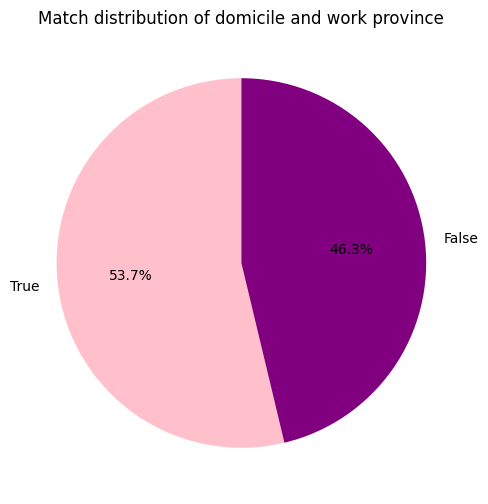

In [37]:
plt.figure(figsize=(6, 6))
dm_df['match'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink', 'purple'], startangle=90)
plt.title("Match distribution of domicile and work province")
plt.ylabel("")  # Hide y-label
plt.show()

The top 10 applicants reside most likely in the province where the job is located, although the margin between the match and the mismatch is not as big as one would expect. 

In [39]:
# Create an independent copy to avoid modifying the original DataFrame
dm_top_applicants = dm_top_applicants.copy()

# Remove leading and trailing whitespace from both columns
dm_top_applicants['cand_domicile_province'] = dm_top_applicants['cand_domicile_province'].str.strip()
dm_top_applicants['job_work_province'] = dm_top_applicants['job_work_province'].str.strip()

# Now perform the comparison
dm_top_applicants['match'] = dm_top_applicants['cand_domicile_province'] == dm_top_applicants['job_work_province']

# Calculate percentages
match_percentage_top = dm_top_applicants['match'].mean() * 100
mismatch_percentage_top = 100 - match_percentage_top

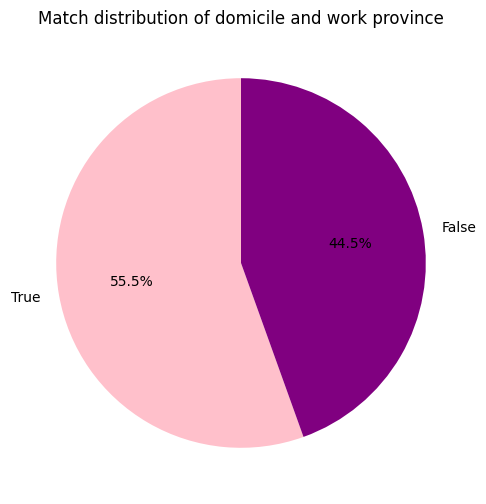

In [40]:
plt.figure(figsize=(6, 6))
dm_top_applicants['match'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink', 'purple'], startangle=90)
plt.title("Match distribution of domicile and work province")
plt.ylabel("")  # Hide y-label
plt.show()